In [37]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
# pd.set_option('display.max_rows', None)

In [38]:
# df = pd.read_excel(r"../data/raw/beds24_bookings_2016_2026.xlsx")
df = pd.read_csv(r"../data/raw/beds24_bookings_2016_2026.csv")
df.head()

,id,masterId,propertyId,roomId,unitId,roomQty,offerId,status,subStatus,arrival,departure,numAdult,numChild,title,firstName,lastName,email,phone,mobile,fax,company,address,city,state,postcode,country,country2,arrivalTime,voucher,comments,notes,message,groupNote,custom1,custom2,custom3,custom4,custom5,custom6,custom7,custom8,custom9,custom10,flagColor,flagText,statusCode,lang,referer,refererEditable,reference,channel,apiSourceId,apiSource,apiReference,allowChannelUpdate,allowAutoAction,allowReview,allowCancellation,invoiceeId,bookingTime,modifiedTime,cancelTime,price,deposit,tax,commission,rateDescription,stripeToken,pcibookingToken,apiMessage
0,37134772,NaN,163277,359135,5,1,1,confirmed,none,2022-12-31,2023-01-04,2,0,NaN,Ruslan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ff7f00,Departed,0,en,kaluku,kaluku,NaN,direct,0,Direct,NaN,all,enable,default,{'type': 'propertyDefault'},NaN,2022-12-31T08:12:51Z,2023-01-18T00:31:12Z,NaN,2300000.0,0,0,0.0,"Offer 1, \r\n2022-12-31 1150000 rate 3884186, ...",NaN,NaN,NaN
1,37133836,NaN,158986,350455,7,1,1,confirmed,none,2022-12-31,2023-01-01,2,0,NaN,Mr,Eza,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,en,abamsgiliair,abamsgiliair,NaN,direct,0,Direct,NaN,all,enable,default,{'type': 'propertyDefault'},NaN,2022-12-31T06:27:12Z,2023-01-15T00:31:21Z,NaN,350000.0,0,0,0.0,350000.00 per malam,NaN,NaN,NaN
2,37133826,NaN,158986,350455,1,1,1,confirmed,none,2022-12-31,2023-01-01,2,0,NaN,Mr,Eza,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,en,abamsgiliair,abamsgiliair,NaN,direct,0,Direct,NaN,all,enable,default,{'type': 'propertyDefault'},NaN,2022-12-31T06:26:06Z,2023-01-15T00:31:21Z,NaN,350000.0,0,0,0.0,350000.00 per malam,NaN,NaN,NaN
3,37115929,NaN,158986,350455,6,1,0,confirmed,none,2022-12-30,2023-01-02,2,0,NaN,Reese,Parrott,rparro.915725@guest.booking.com,+62 2035640799,NaN,NaN,NaN,"30 08 Prudential Tower, 19 Cecil St",bangkok,NaN,NaN,id,ID,NaN,NaN,** THIS RESERVATION HAS BEEN PRE-PAID **\nLarg...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,Booking.com,Booking.com,NaN,booking,19,Booking.com,3918534202,all,enable,default,{'type': 'propertyDefault'},NaN,2022-12-30T11:27:43Z,2023-01-16T00:31:46Z,NaN,1428030.0,0,0,289890.0,2022-12-30 Rate (30739057 Standard Flexible re...,NaN,NaN,NaN
4,37112201,NaN,179195,388813,1,1,0,confirmed,none,2022-12-31,2023-01-03,1,0,NaN,Annalisa,Giampietro,agiamp.692066@guest.booking.com,+62 878 6519 1998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,id,ID,NaN,NaN,Approximate time of arrival: between 12:00 and...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,Booking.com,Booking.com,NaN,booking,19,Booking.com,2668644866,all,enable,default,{'type': 'propertyDefault'},NaN,2022-12-30T08:28:43Z,2023-01-17T00:31:11Z,NaN,2341750.0,0,0,421515.0,2022-12-31 Rate (1450640 Standard Rate rewritt...,NaN,NaN,NaN


In [39]:
df_old = df.copy()

In [40]:
df = df_old.copy()

In [41]:
duplicate_rows = len(df) - len(df.drop_duplicates())
duplicate_rows
print(f"Jumlah duplikat sebelum dihapus: {duplicate_rows}")

# Menghapus duplikat
df = df.drop_duplicates()
duplicate_rows_after = len(df) - len(df.drop_duplicates())  
print(f"Jumlah duplikat setelah dihapus: {duplicate_rows_after}")

Jumlah duplikat sebelum dihapus: 465323
Jumlah duplikat setelah dihapus: 0


In [42]:
import pandas as pd

# =========================================================
# 1. PREPARE THE ROOMS DATAFRAME
# =========================================================
df_rooms = pd.read_csv("../data/raw/room_qty.csv")
# Note: Added column names here just in case your CSV doesn't have headers. 
# Adjust as needed to ensure 'roomId' and 'qty' are mapped perfectly.
df_rooms.rename(columns={'room_id': 'roomId', 'quantity': 'qty'}, inplace=True)

# =========================================================
# 2. CLEAN AND PREPARE BOOKING DATA
# =========================================================
# Ensure dates are purely dates (stripping out any time data to prevent range errors)
df['arrival'] = pd.to_datetime(df['arrival'], errors='coerce').dt.normalize()
df['departure'] = pd.to_datetime(df['departure'], errors='coerce').dt.normalize()

# Ensure roomQty is a number (filling any blanks with 1)
df['roomQty'] = pd.to_numeric(df['roomQty'], errors='coerce').fillna(1)

# THE BIG FIX: Deduplicate by the actual reservation ID, not the row log ID.
# If you have a 'modifiedTime' or 'bookingTime' column, sort by it first 
# so keep='last' truly keeps the most recent update.
if 'modifiedTime' in df.columns:
    df = df.sort_values('modifiedTime')
# df = df.drop_duplicates(subset=['masterId'], keep='last')

# Filter for valid statuses
df = df[df['status'].isin(['confirmed', 'new'])]

# =========================================================
# 3. CALCULATE USED ROOM-NIGHTS PER MONTH
# =========================================================
df['stay_dates'] = df.apply(
    lambda row: pd.date_range(start=row['arrival'], end=row['departure'] - pd.Timedelta(days=1)).tolist() 
    if pd.notnull(row['arrival']) and pd.notnull(row['departure']) and row['arrival'] < row['departure']
    else [], 
    axis=1
)

df_exploded = df.explode('stay_dates')
df_exploded['month_period'] = df_exploded['stay_dates'].dt.to_period('M').astype(str)

# Sum the actual room quantity rather than just counting the rows
df_usage = df_exploded.groupby(['roomId', 'month_period'])['roomQty'].sum().reset_index(name='used_room_nights')

df_usage['roomId'] = df_usage['roomId'].astype(int)


# =========================================================
# 4. CALCULATE TOTAL CAPACITY & LEFTOVER ROOMS
# =========================================================
all_months = df_exploded['month_period'].unique()

from itertools import product
all_combinations = pd.DataFrame(
    list(product(df_rooms['roomId'].unique(), all_months)), 
    columns=['roomId', 'month_period']
)

monthly_stats = all_combinations.merge(df_rooms[['roomId', 'qty']], on='roomId', how='left')

monthly_stats['month_date'] = pd.to_datetime(monthly_stats['month_period'])

def adjust_qty(row):
    d = row['month_date']
    rid = row['roomId']

    # --- ROOM 350464 ---
    if rid == 350464:
        if d < pd.Timestamp('2023-12-01'):
            return 12
        elif d < pd.Timestamp('2024-06-01'):
            return 6
        else:
            return 5

    # --- ROOM 462632 ---
    if rid == 462632:
        if d < pd.Timestamp('2023-12-01'):
            return 0
        else:
            return 4

    # --- ROOM 462634 ---
    if rid == 462634:
        if d < pd.Timestamp('2023-12-01'):
            return 0
        else:
            return 2

    # --- ROOM 462631 ---
    if rid == 462631:
        if d < pd.Timestamp('2023-11-01'):
            return 0
        else:
            return 1

    # --- ROOM 502851 ---
    if rid == 502851:
        if d < pd.Timestamp('2024-06-01'):
            return 0
        else:
            return 1

    # default → keep original
    return row['qty']


monthly_stats['qty'] = monthly_stats.apply(adjust_qty, axis=1)

# monthly_stats['roomId'] = monthly_stats['roomId'].astype(int)
monthly_stats['days_in_month'] = pd.to_datetime(monthly_stats['month_period']).dt.daysinmonth
monthly_stats['total_capacity_nights'] = monthly_stats['qty'] * monthly_stats['days_in_month']

monthly_stats = monthly_stats.merge(df_usage, on=['roomId', 'month_period'], how='left')
monthly_stats['used_room_nights'] = monthly_stats['used_room_nights'].fillna(0)

monthly_stats['leftover_rooms'] = monthly_stats['total_capacity_nights'] - monthly_stats['used_room_nights']

In [43]:
df.drop(columns=['stay_dates'], inplace=True)

In [44]:
# filt = df['stay_dates'].apply(
#     lambda dates: any(d.year == 2026 and d.month == 6 for d in dates)
# )

# filt_2 = df['roomId'] == 350455
# df[(filt & filt_2)]

In [45]:
filt = (df_rooms["roomId"] == 359142)
df_rooms[filt]

,property_id,property_name,roomId,room_name,qty
12,163277,Kaluku Gili Resort,359142,Deluxe Pool View,10


In [46]:
filt = (monthly_stats['leftover_rooms'] < 0)
minus_stat = monthly_stats[filt]
minus_stat['property'] = minus_stat['roomId'].apply(lambda x: df_rooms[df_rooms['roomId'] == x]['property_name'].iloc[0] if x in df_rooms['roomId'].values else 'Unknown')
minus_stat['room'] = minus_stat['roomId'].apply(lambda x: df_rooms[df_rooms['roomId'] == x]['room_name'].iloc[0] if x in df_rooms['roomId'].values else 'Unknown')
minus_stat

,roomId,month_period,qty,month_date,days_in_month,total_capacity_nights,used_room_nights,leftover_rooms,property,room
98,350464,2025-10,5,2025-10-01,31,155,196.0,-41.0,Pandan Bungalow,Superior Bungalow
194,462632,2024-08,4,2024-08-01,31,124,125.0,-1.0,Pandan Bungalow,Deluxe Room
281,502851,2022-07,0,2022-07-01,31,0,2.0,-2.0,Pandan Bungalow,Deluxe Bungalow
325,502851,2026-01,1,2026-01-01,31,31,32.0,-1.0,Pandan Bungalow,Deluxe Bungalow
358,354680,2024-04,1,2024-04-01,30,30,31.0,-1.0,Mantra Gili,King Room with Balcony
362,354680,2024-08,1,2024-08-01,31,31,38.0,-7.0,Mantra Gili,King Room with Balcony
414,354681,2024-04,1,2024-04-01,30,30,33.0,-3.0,Mantra Gili,King Room with Pool View
417,354681,2024-07,1,2024-07-01,31,31,32.0,-1.0,Mantra Gili,King Room with Pool View
418,354681,2024-08,1,2024-08-01,31,31,39.0,-8.0,Mantra Gili,King Room with Pool View
474,354682,2024-08,4,2024-08-01,31,124,136.0,-12.0,Mantra Gili,Deluxe Double or Twin Room with Pool Access


In [47]:
# Filter booking.com doang channelnya
filt_channel = (df['channel'] == 'booking')
df = df[filt_channel]

In [48]:
len(df)

24810

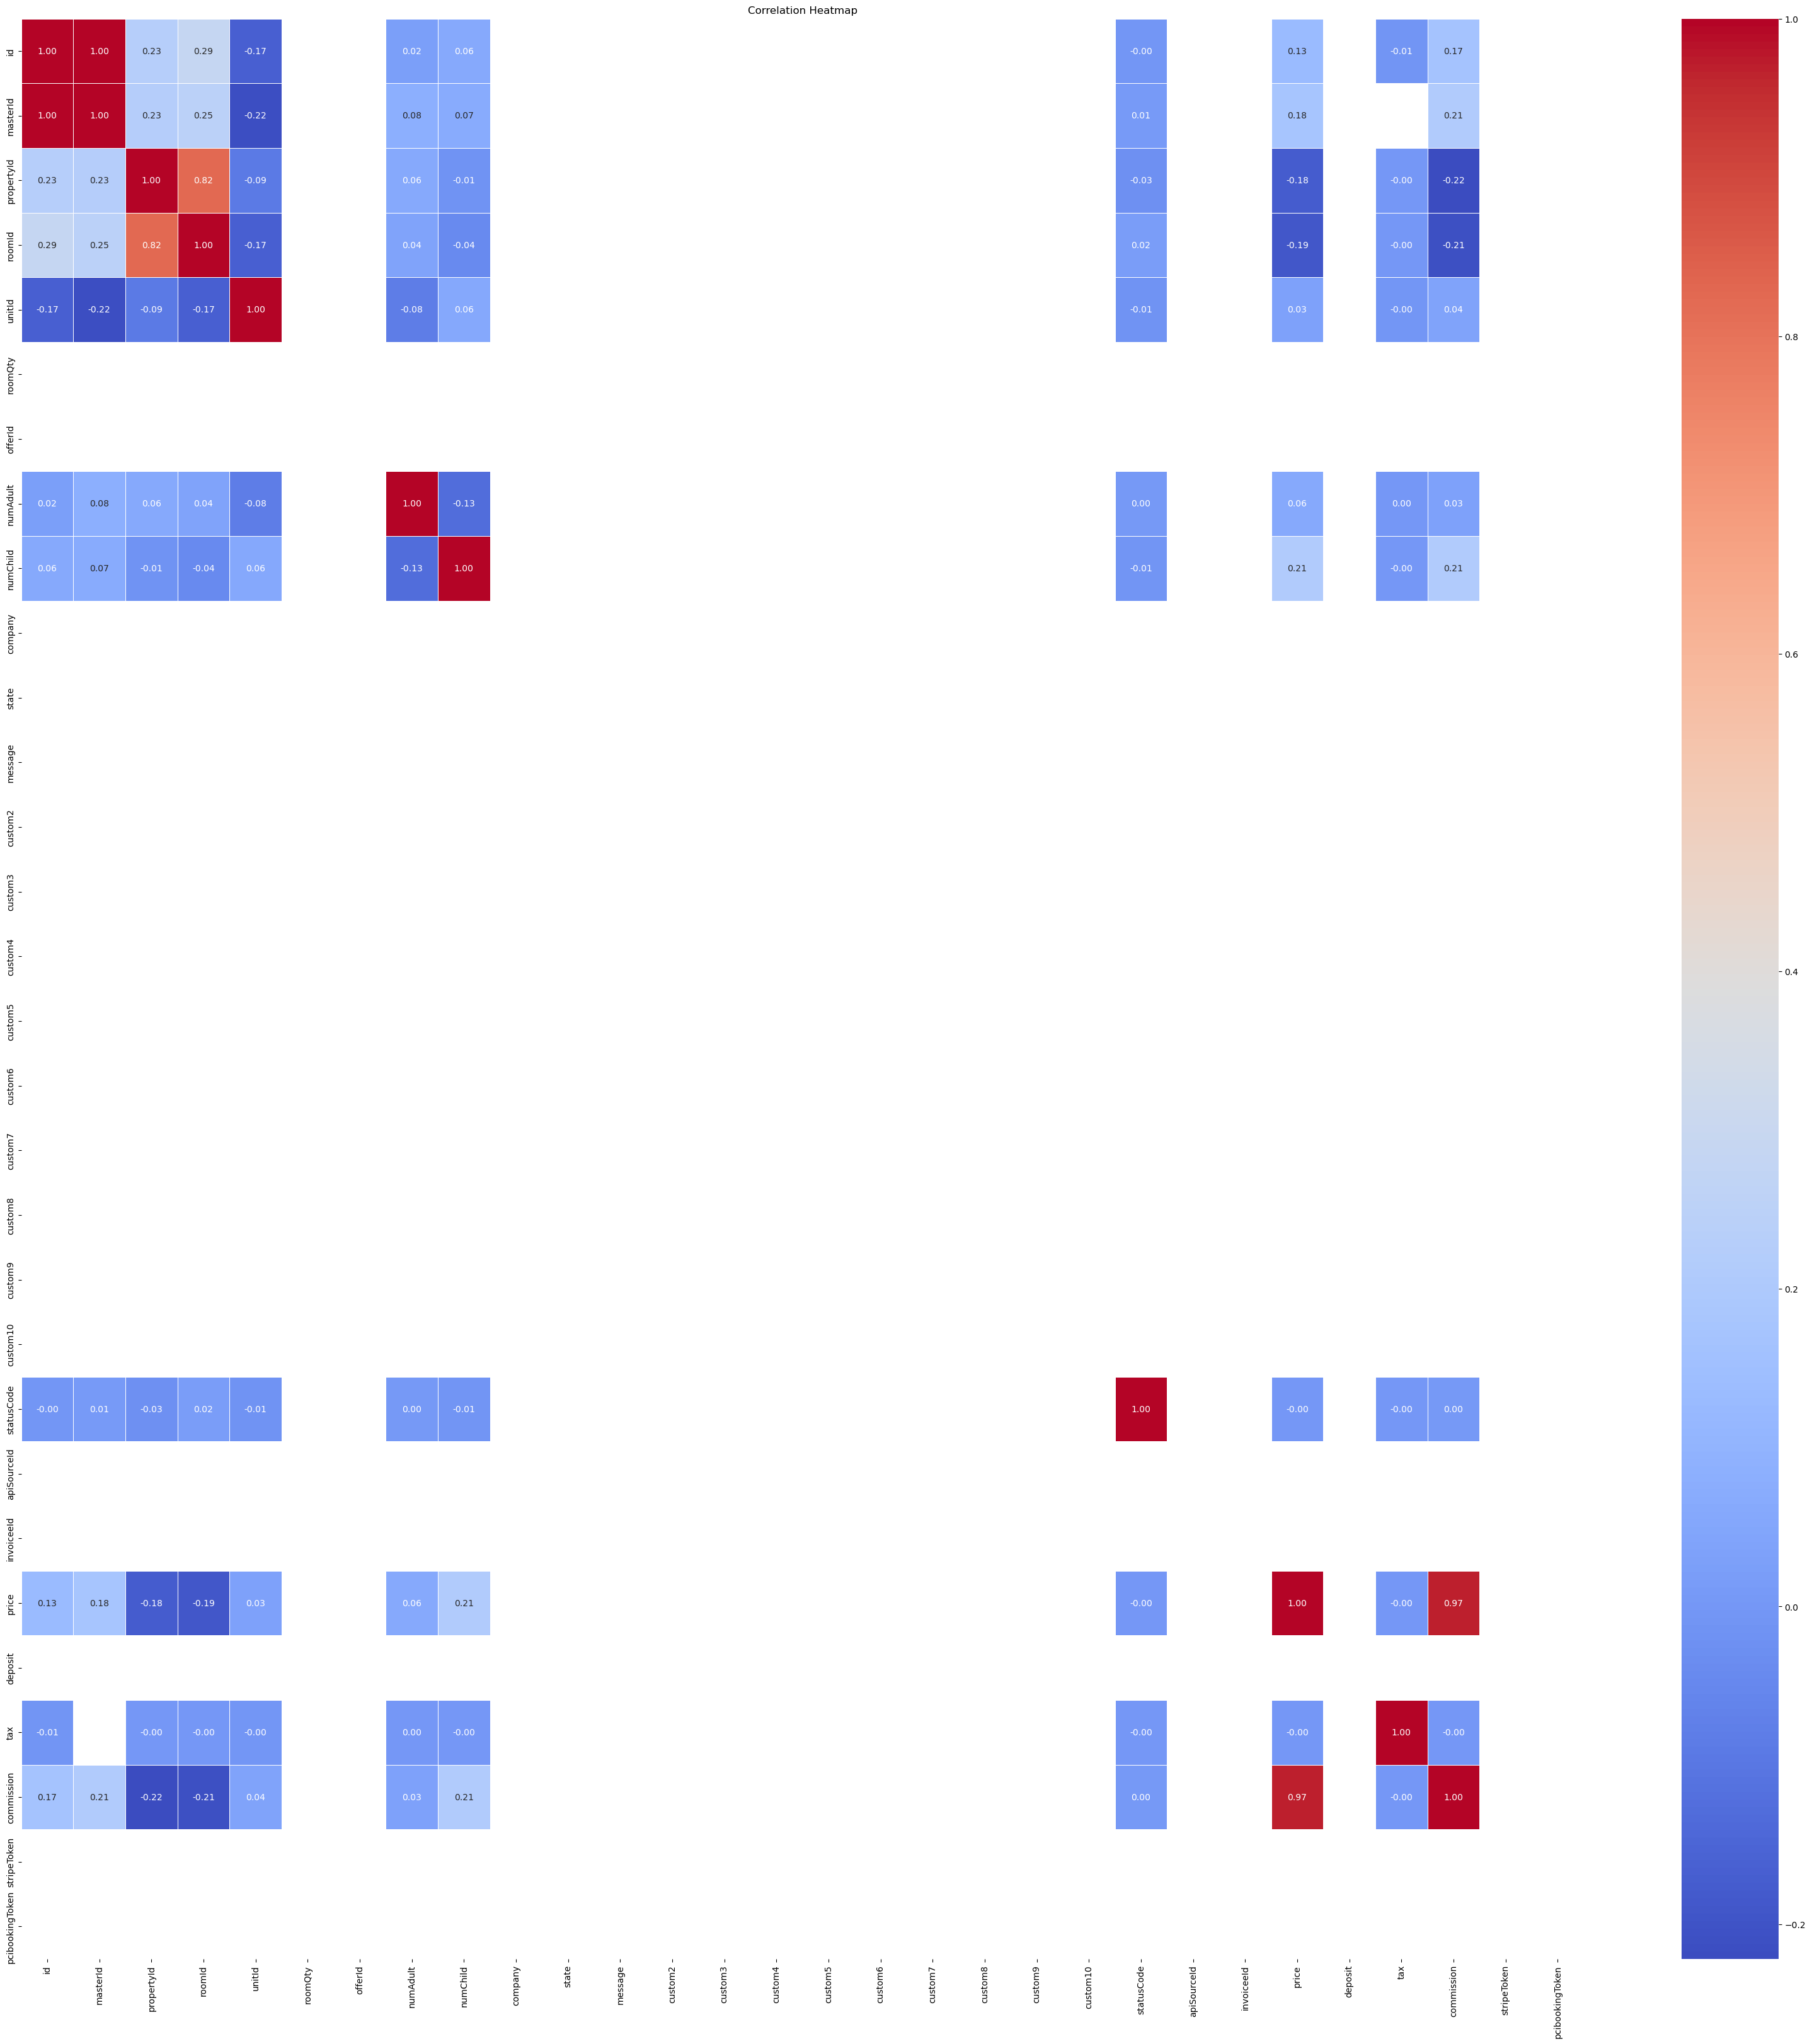

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

matrix = df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(40, 40))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [50]:
df_num = df.select_dtypes(include=['number'])
num_col = df_num.columns
df_corr = df_num.corr().abs()['price'] 
mask_corr = df_corr > 0.1
high_cor_col = df_corr[mask_corr].keys().to_list()


In [51]:
df_no_num = df.drop(labels=num_col, axis=1)

In [52]:
df_no_num.columns.to_list() + high_cor_col

['status',
 'subStatus',
 'arrival',
 'departure',
 'title',
 'firstName',
 'lastName',
 'email',
 'phone',
 'mobile',
 'fax',
 'address',
 'city',
 'postcode',
 'country',
 'country2',
 'arrivalTime',
 'voucher',
 'comments',
 'notes',
 'groupNote',
 'custom1',
 'flagColor',
 'flagText',
 'lang',
 'referer',
 'refererEditable',
 'reference',
 'channel',
 'apiSource',
 'apiReference',
 'allowChannelUpdate',
 'allowAutoAction',
 'allowReview',
 'allowCancellation',
 'bookingTime',
 'modifiedTime',
 'cancelTime',
 'rateDescription',
 'apiMessage',
 'id',
 'masterId',
 'propertyId',
 'roomId',
 'numChild',
 'price',
 'commission']

In [53]:
high_cor_col

['id', 'masterId', 'propertyId', 'roomId', 'numChild', 'price', 'commission']

In [54]:
df_no_num.columns.to_list().append(high_cor_col)

In [55]:
df = pd.concat([df_no_num, df_num[high_cor_col]], axis=1, ignore_index=True)
df.columns = (df_no_num.columns.to_list() + high_cor_col)
df.head(15)

,status,subStatus,arrival,departure,title,firstName,lastName,email,phone,mobile,fax,address,city,postcode,country,country2,arrivalTime,voucher,comments,notes,groupNote,custom1,flagColor,flagText,lang,referer,refererEditable,reference,channel,apiSource,apiReference,allowChannelUpdate,allowAutoAction,allowReview,allowCancellation,bookingTime,modifiedTime,cancelTime,rateDescription,apiMessage,id,masterId,propertyId,roomId,numChild,price,commission
1947,confirmed,none,2022-06-12,2022-06-15,NaN,Josefina,Dufvenberg,jdufve.330013@guest.booking.com,+46 70 528 60 00,NaN,NaN,Smidesvagen 17,Kungsbacka,43440,se,SE,NaN,NaN,BED PREFERENCE:Deluxe Double or Twin Room with...,NaN,NaN,NaN,0000ff,Paid,NaN,Booking.com,Booking.com,NaN,booking,Booking.com,2665654753,all,enable,default,{'type': 'propertyDefault'},2022-06-10T10:19:43Z,2022-06-29T00:31:27Z,NaN,2022-06-12 Rate (16464056 Standard Rate rewrit...,NaN,31711388,NaN,161014,354682,0,1215000.0,218700.0
1948,confirmed,none,2022-06-11,2022-06-15,NaN,SANGJIN,PARK,spark.204982@guest.booking.com,+62 2035640799,NaN,NaN,"30 08 Prudential Tower, 19 Cecil St",bangkok,N&#47;A,id,ID,NaN,NaN,"LargeBed, NonSmoke AdditionalNotes: High floor...",NaN,NaN,NaN,0000ff,Paid,NaN,Booking.com,Booking.com,NaN,booking,Booking.com,3247470854,all,enable,default,{'type': 'propertyDefault'},2022-06-10T03:53:02Z,2022-06-29T00:31:27Z,NaN,2022-06-11 Rate (16464056 Standard Rate rewrit...,NaN,31705234,NaN,161014,354683,0,1620000.0,291600.0
1936,confirmed,none,2022-06-14,2022-06-16,NaN,Michaela,Kacrova,mkacro.802481@guest.booking.com,+420 777 901 080,NaN,NaN,Francouzska 454/74,Prague,NaN,cz,CZ,NaN,NaN,Genius Free Room Upgrade booking to attract to...,Transferred from Deluxe Double or Twin Room wi...,NaN,NaN,0000ff,Paid,NaN,Booking.com,Booking.com,NaN,booking,Booking.com,3397365503,all,enable,default,{'type': 'propertyDefault'},2022-06-13T23:52:46Z,2022-06-30T00:31:36Z,NaN,2022-06-14 Rate (16464056 Standard Rate rewrit...,NaN,31806346,NaN,161014,354680,0,972000.0,174960.0
1957,confirmed,none,2022-06-14,2022-06-17,NaN,HYUNA,LIM,hlim.672342@guest.booking.com,+82 10 6708 8208,NaN,NaN,NaN,.,NaN,kr,KR,NaN,NaN,Guest name: LIM HYUNA\nGenius Free Room Upgrad...,NaN,NaN,NaN,0000ff,Paid,NaN,Booking.com,Booking.com,NaN,booking,Booking.com,3653931656,all,enable,default,{'type': 'propertyDefault'},2022-05-26T06:22:04Z,2022-07-01T00:31:34Z,NaN,2022-06-14 Rate (16464056 Standard Rate rewrit...,NaN,31219249,NaN,161014,354682,0,1215000.0,218700.0
1937,new,none,2022-06-14,2022-06-17,NaN,Edgar,Rodriguez,erodri.518595@guest.booking.com,+65 2035640799,NaN,NaN,"30 08 Prudential Tower, 19 Cecil St",bangkok,N&#47;A,sg,SG,NaN,NaN,** THIS RESERVATION HAS BEEN PRE-PAID **\nBOOK...,NaN,NaN,NaN,NaN,NaN,NaN,Booking.com,Booking.com,NaN,booking,Booking.com,2363877398,all,enable,default,{'type': 'propertyDefault'},2022-06-13T03:55:35Z,2022-07-01T00:31:38Z,NaN,2022-06-14 Rate (26270295 Standard Rate rewrit...,NaN,31777660,NaN,158986,350455,0,787500.0,175612.0
1940,confirmed,none,2022-06-14,2022-06-17,NaN,arran,doran,adoran.532441@guest.booking.com,+61 492 851 200,NaN,NaN,NaN,.,NaN,au,AU,NaN,NaN,Genius Free Room Upgrade booking to attract to...,Transferred from Deluxe Double or Twin Room wi...,NaN,NaN,0000ff,Paid,en,Booking.com,Booking.com,NaN,booking,Booking.com,3594126707,all,enable,default,{'type': 'propertyDefault'},2022-06-12T01:12:30Z,2022-07-01T00:31:38Z,NaN,2022-06-14 Rate (16464056 Standard Rate rewrit...,NaN,31751703,31751702.0,161014,354682,0,1215000.0,218700.0
1941,confirmed,none,2022-06-14,2022-06-17,NaN,arran,doran,adoran.532441@guest.booking.com,+61 492 851 200,NaN,NaN,NaN,.,NaN,au,AU,NaN,NaN,Genius Free Room Upgrade booking to attract to...,Transferred from Deluxe Double or Twin Room wi...,NaN,NaN,0000ff,Paid,en,Booking.com,Booking.com,NaN,booking,Booking.com,3594126707,all,enable,default,{'type': 'propertyDefault'},2022-06-12T01:12:29Z,2022-07-01T00:31:38Z,NaN,2022-06-14 Rate (16464056 Standard Rate rewrit...,NaN,31751702,NaN,161014,354682,0,121

In [56]:
def nan_rat():
    print(df.isna().sum()/len(df))

nan_rat()

status                0.000000
subStatus             0.000000
arrival               0.000000
departure             0.000000
title                 0.999758
firstName             0.000081
lastName              0.000846
email                 0.012173
phone                 0.012213
mobile                1.000000
fax                   1.000000
address               0.815397
city                  0.304514
postcode              0.940105
country               0.012173
country2              0.012777
arrivalTime           0.999879
voucher               0.999960
comments              0.012173
notes                 0.913341
groupNote             0.999960
custom1               0.999678
flagColor             0.410278
flagText              0.445304
lang                  0.712576
referer               0.000000
refererEditable       0.000000
reference             0.999758
channel               0.000000
apiSource             0.000000
apiReference          0.000000
allowChannelUpdate    0.000000
allowAut

In [57]:
# Ngisi NaN Numerik
df_num = df.select_dtypes(include=['number'])
num_col = df_num.columns

mean_num_col = np.mean(df[num_col], axis=0)
df[num_col] = df[num_col].fillna(mean_num_col)

In [58]:
# Ngisi NaN Kategorikal
df_cat = df.select_dtypes(include=['object'])
cat_col = df_cat.columns
modes_cat_col = df_cat.mode().loc[0].to_dict()
df[cat_col] = df[cat_col].fillna(modes_cat_col)

In [59]:
nan_rat()

status                0.0
subStatus             0.0
arrival               0.0
departure             0.0
title                 0.0
firstName             0.0
lastName              0.0
email                 0.0
phone                 0.0
mobile                1.0
fax                   1.0
address               0.0
city                  0.0
postcode              0.0
country               0.0
country2              0.0
arrivalTime           0.0
voucher               0.0
comments              0.0
notes                 0.0
groupNote             0.0
custom1               0.0
flagColor             0.0
flagText              0.0
lang                  0.0
referer               0.0
refererEditable       0.0
reference             0.0
channel               0.0
apiSource             0.0
apiReference          0.0
allowChannelUpdate    0.0
allowAutoAction       0.0
allowReview           0.0
allowCancellation     0.0
bookingTime           0.0
modifiedTime          0.0
cancelTime            0.0
rateDescript

In [60]:
df.head(15)

,status,subStatus,arrival,departure,title,firstName,lastName,email,phone,mobile,fax,address,city,postcode,country,country2,arrivalTime,voucher,comments,notes,groupNote,custom1,flagColor,flagText,lang,referer,refererEditable,reference,channel,apiSource,apiReference,allowChannelUpdate,allowAutoAction,allowReview,allowCancellation,bookingTime,modifiedTime,cancelTime,rateDescription,apiMessage,id,masterId,propertyId,roomId,numChild,price,commission
1947,confirmed,none,2022-06-12,2022-06-15,RO,Josefina,Dufvenberg,jdufve.330013@guest.booking.com,+46 70 528 60 00,NaN,NaN,Smidesvagen 17,Kungsbacka,43440,se,SE,16.3,geniuscm,BED PREFERENCE:Deluxe Double or Twin Room with...,Booked Villa with Private Pool - 419106\n,Room Only,Paid OTA,0000ff,Paid,en,Booking.com,Booking.com,45867993 marie,booking,Booking.com,2665654753,all,enable,default,{'type': 'propertyDefault'},2022-06-10T10:19:43Z,2022-06-29T00:31:27Z,2024-08-05T03:15:10Z,2022-06-12 Rate (16464056 Standard Rate rewrit...,Room: Villa with Private Pool\nThe unit offers...,31711388,5.762940e+07,161014,354682,0,1215000.0,218700.0
1948,confirmed,none,2022-06-11,2022-06-15,RO,SANGJIN,PARK,spark.204982@guest.booking.com,+62 2035640799,NaN,NaN,"30 08 Prudential Tower, 19 Cecil St",bangkok,N&#47;A,id,ID,16.3,geniuscm,"LargeBed, NonSmoke AdditionalNotes: High floor...",Booked Villa with Private Pool - 419106\n,Room Only,Paid OTA,0000ff,Paid,en,Booking.com,Booking.com,45867993 marie,booking,Booking.com,3247470854,all,enable,default,{'type': 'propertyDefault'},2022-06-10T03:53:02Z,2022-06-29T00:31:27Z,2024-08-05T03:15:10Z,2022-06-11 Rate (16464056 Standard Rate rewrit...,Room: Villa with Private Pool\nThe unit offers...,31705234,5.762940e+07,161014,354683,0,1620000.0,291600.0
1936,confirmed,none,2022-06-14,2022-06-16,RO,Michaela,Kacrova,mkacro.802481@guest.booking.com,+420 777 901 080,NaN,NaN,Francouzska 454/74,Prague,049712,cz,CZ,16.3,geniuscm,Genius Free Room Upgrade booking to attract to...,Transferred from Deluxe Double or Twin Room wi...,Room Only,Paid OTA,0000ff,Paid,en,Booking.com,Booking.com,45867993 marie,booking,Booking.com,3397365503,all,enable,default,{'type': 'propertyDefault'},2022-06-13T23:52:46Z,2022-06-30T00:31:36Z,2024-08-05T03:15:10Z,2022-06-14 Rate (16464056 Standard Rate rewrit...,Room: Villa with Private Pool\nThe unit offers...,31806346,5.762940e+07,161014,354680,0,972000.0,174960.0
1957,confirmed,none,2022-06-14,2022-06-17,RO,HYUNA,LIM,hlim.672342@guest.booking.com,+82 10 6708 8208,NaN,NaN,"30 08 Prudential Tower, 19 Cecil St",.,049712,kr,KR,16.3,geniuscm,Guest name: LIM HYUNA\nGenius Free Room Upgrad...,Booked Villa with Private Pool - 419106\n,Room Only,Paid OTA,0000ff,Paid,en,Booking.com,Booking.com,45867993 marie,booking,Booking.com,3653931656,all,enable,default,{'type': 'propertyDefault'},2022-05-26T06:22:04Z,2022-07-01T00:31:34Z,2024-08-05T03:15:10Z,2022-06-14 Rate (16464056 Standard Rate rewrit...,Room: Villa with Private Pool\nThe unit offers...,31219249,5.762940e+07,161014,354682,0,1215000.0,218700.0
1937,new,none,2022-06-14,2022-06-17,RO,Edgar,Rodriguez,erodri.518595@guest.booking.com,+65 2035640799,NaN,NaN,"30 08 Prudential Tower, 19 Cecil St",bangkok,N&#47;A,sg,SG,16.3,geniuscm,** THIS RESERVATION HAS BEEN PRE-PAID **\nBOOK...,Booked Villa with Private Pool - 419106\n,Room Only,Paid OTA,ff7f00,Paid,en,Booking.com,Booking.com,45867993 marie,booking,Booking.com,2363877398,all,enable,default,{'type': 'propertyDefault'},2022-06-13T03:55:35Z,2022-07-01T00:31:38Z,2024-08-05T03:15:10Z,2022-06-14 Rate (26270295 Standard Rate rewrit...,Room: Villa with Private Pool\nThe unit offers...,31777660,5.762940e+07,158986,350455,0,787500.0,175612.0
1940,confirmed,none,2022-06-14,2022-06-17,RO,arran,doran,adoran.532441@guest.booking.com,+61 492 851 200,NaN,NaN,"30 08 Prudential Tower, 19 Cecil St",.,049712,au,AU,16.3,geniuscm,Genius Free Room Upgrade booking to attract to...,Transferred from Deluxe Double or Twin Room wi...,Room Only,Paid OTA,0000ff,Paid,en,Booking.com,Booking.c

In [61]:
df = df.dropna(how='all', axis=1)

In [62]:
nan_rat()

status                0.0
subStatus             0.0
arrival               0.0
departure             0.0
title                 0.0
firstName             0.0
lastName              0.0
email                 0.0
phone                 0.0
address               0.0
city                  0.0
postcode              0.0
country               0.0
country2              0.0
arrivalTime           0.0
voucher               0.0
comments              0.0
notes                 0.0
groupNote             0.0
custom1               0.0
flagColor             0.0
flagText              0.0
lang                  0.0
referer               0.0
refererEditable       0.0
reference             0.0
channel               0.0
apiSource             0.0
apiReference          0.0
allowChannelUpdate    0.0
allowAutoAction       0.0
allowReview           0.0
allowCancellation     0.0
bookingTime           0.0
modifiedTime          0.0
cancelTime            0.0
rateDescription       0.0
apiMessage            0.0
id          

In [63]:
df['arrival'] = pd.to_datetime(df['arrival'])
df['departure'] = pd.to_datetime(df['departure'])
df['bookingTime'] = pd.to_datetime(df['bookingTime']).dt.tz_localize(None)

In [64]:
df['range_booking_arrival']  = abs((df['bookingTime'] - df['arrival']).dt.days)

In [65]:
df['num_of_nights'] = (df['departure'] - df['arrival']).dt.days

In [66]:
df['price_per_day'] = df['price'] / df['num_of_nights']

In [67]:
# Setting the 'Datetime' column as the index of the DataFrame
df = df.set_index('arrival')

# Ensuring that the index is of datetime type
df.index = pd.to_datetime(df.index)

# Generating descriptive statistics of the DataFrame
df.describe()

,departure,bookingTime,id,masterId,propertyId,roomId,numChild,price,commission,range_booking_arrival,num_of_nights,price_per_day
count,24810,24810,2.481000e+04,2.481000e+04,24810.000000,24810.000000,24810.000000,2.481000e+04,2.481000e+04,24810.000000,24810.000000,2.481000e+04
mean,2024-07-18 21:37:44.474002688,2024-06-07 15:14:58.238129920,5.681701e+07,5.762940e+07,177521.452519,391667.547561,0.076945,2.078618e+06,3.905880e+05,38.927449,2.804313,7.166969e+05
min,2022-06-15 00:00:00,2022-05-18 15:01:45,3.101578e+07,3.173108e+07,158986.000000,350455.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,1.000000,0.000000e+00
25%,2023-10-04 00:00:00,2023-09-08 22:45:42,4.622055e+07,5.762940e+07,161014.000000,354683.000000,0.000000,7.920000e+05,1.422960e+05,1.000000,2.000000,4.050000e+05
50%,2024-07-28 00:00:00,2024-06-06 12:56:06,5.603765e+07,5.762940e+07,163277.000000,381255.000000,0.000000,1.530000e+06,2.839150e+05,7.000000,3.000000,6.203895e+05
75%,2025-05-14 00:00:00,2025-03-25 15:44:00.249999872,6.781574e+07,5.762940e+07,193394.000000,419105.000000,0.000000,2.760087e+06,5.190232e+05,53.000000,3.000000,9.294750e+05
max,2027-01-03 00:00:00,2026-01-27 02:24:39,8.144071e+07,8.142458e+07,243134.000000,622210.000000,5.000000,3.266941e+07,4.900411e+06,368.000000,36.000000,1.026027e+07
std,NaN,NaN,1.291762e+07,5.492524e+06,21422.677781,43873.544473,0.293020,1.909404e+06,3.721136e+05,60.094998,1.890114,4.422369e+05


In [68]:
df.sort_index(inplace=True)
df.head()

,status,subStatus,departure,title,firstName,lastName,email,phone,address,city,postcode,country,country2,arrivalTime,voucher,comments,notes,groupNote,custom1,flagColor,flagText,lang,referer,refererEditable,reference,channel,apiSource,apiReference,allowChannelUpdate,allowAutoAction,allowReview,allowCancellation,bookingTime,modifiedTime,cancelTime,rateDescription,apiMessage,id,masterId,propertyId,roomId,numChild,price,commission,range_booking_arrival,num_of_nights,price_per_day
arrival,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2022-06-11,confirmed,none,2022-06-15,RO,SANGJIN,PARK,spark.204982@guest.booking.com,+62 2035640799,"30 08 Prudential Tower, 19 Cecil St",bangkok,N&#47;A,id,ID,16.3,geniuscm,"LargeBed, NonSmoke AdditionalNotes: High floor...",Booked Villa with Private Pool - 419106\n,Room Only,Paid OTA,0000ff,Paid,en,Booking.com,Booking.com,45867993 marie,booking,Booking.com,3247470854,all,enable,default,{'type': 'propertyDefault'},2022-06-10 03:53:02,2022-06-29T00:31:27Z,2024-08-05T03:15:10Z,2022-06-11 Rate (16464056 Standard Rate rewrit...,Room: Villa with Private Pool\nThe unit offers...,31705234,5.762940e+07,161014,354683,0,1620000.0,291600.0,1,4,405000.0
2022-06-12,confirmed,none,2022-06-15,RO,Josefina,Dufvenberg,jdufve.330013@guest.booking.com,+46 70 528 60 00,Smidesvagen 17,Kungsbacka,43440,se,SE,16.3,geniuscm,BED PREFERENCE:Deluxe Double or Twin Room with...,Booked Villa with Private Pool - 419106\n,Room Only,Paid OTA,0000ff,Paid,en,Booking.com,Booking.com,45867993 marie,booking,Booking.com,2665654753,all,enable,default,{'type': 'propertyDefault'},2022-06-10 10:19:43,2022-06-29T00:31:27Z,2024-08-05T03:15:10Z,2022-06-12 Rate (16464056 Standard Rate rewrit...,Room: Villa with Private Pool\nThe unit offers...,31711388,5.762940e+07,161014,354682,0,1215000.0,218700.0,2,3,405000.0
2022-06-14,confirmed,none,2022-06-16,RO,Michaela,Kacrova,mkacro.802481@guest.booking.com,+420 777 901 080,Francouzska 454/74,Prague,049712,cz,CZ,16.3,geniuscm,Genius Free Room Upgrade booking to attract to...,Transferred from Deluxe Double or Twin Room wi...,Room Only,Paid OTA,0000ff,Paid,en,Booking.com,Booking.com,45867993 marie,booking,Booking.com,3397365503,all,enable,default,{'type': 'propertyDefault'},2022-06-13 23:52:46,2022-06-30T00:31:36Z,2024-08-05T03:15:10Z,2022-06-14 Rate (16464056 Standard Rate rewrit...,Room: Villa with Private Pool\nThe unit offers...,31806346,5.762940e+07,161014,354680,0,972000.0,174960.0,1,2,486000.0
2022-06-14,confirmed,none,2022-06-17,RO,HYUNA,LIM,hlim.672342@guest.booking.com,+82 10 6708 8208,"30 08 Prudential Tower, 19 Cecil St",.,049712,kr,KR,16.3,geniuscm,Guest name: LIM HYUNA\nGenius Free Room Upgrad...,Booked Villa with Private Pool - 419106\n,Room Only,Paid OTA,0000ff,Paid,en,Booking.com,Booking.com,45867993 marie,booking,Booking.com,3653931656,all,enable,default,{'type': 'propertyDefault'},2022-05-26 06:22:04,2022-07-01T00:31:34Z,2024-08-05T03:15:10Z,2022-06-14 Rate (16464056 Standard Rate rewrit...,Room: Villa with Private Pool\nThe unit offers...,31219249,5.762940e+07,161014,354682,0,1215000.0,218700.0,19,3,405000.0
2022-06-14,new,none,2022-06-17,RO,Edgar,Rodriguez,erodri.518595@guest.booking.com,+65 2035640799,"30 08 Prudential Tower, 19 Cecil St",bangkok,N&#47;A,sg,SG,16.3,geniuscm,** THIS RESERVATION HAS BEEN PRE-PAID **\nBOOK...,Booked Villa with Private Pool - 419106\n,Room Only,Paid OTA,ff7f00,Paid,en,Booking.com,Booking.com,45867993 marie,booking,Booking.com,2363877398,all,enable,default,{'type': 'propertyDefault'},2022-06-13 03:55:35,2022-07-01T00:31:38Z,2024-08-05T03:15:10Z,2022-06-14 Rate (26270295 Standard Rate rewrit...,Room: Villa with Private Pool\nThe unit offers...,31777660,5.762940e+07,158986,350455,0,787500.0,175612.0,1,3,262500.0


In [69]:
cat_col = df.select_dtypes(include=['object']).columns
mask_many_cat = (df[cat_col].nunique() > 6)
many_cat_col = cat_col[mask_many_cat]
small_cat_col = cat_col[(mask_many_cat != True)]

In [71]:
from sklearn.preprocessing import OneHotEncoder 
df[small_cat_col] = df[small_cat_col].fillna('missing').astype(str)
onehot_start = OneHotEncoder(sparse_output=False)
one_hot_encoded = onehot_start.fit_transform(df[small_cat_col])
one_hot_df = pd.DataFrame(one_hot_encoded, 
                          columns=onehot_start.get_feature_names_out(small_cat_col), index=df.index)

df_sklearn_encoded = pd.concat([df.drop(small_cat_col, axis=1), one_hot_df], axis=1)

In [72]:
df_sklearn_encoded.head()

,departure,firstName,lastName,email,phone,address,city,postcode,country,country2,comments,notes,flagColor,flagText,lang,apiReference,bookingTime,modifiedTime,rateDescription,apiMessage,id,masterId,propertyId,roomId,numChild,price,commission,range_booking_arrival,num_of_nights,price_per_day,status_confirmed,status_new,subStatus_noShow,subStatus_nonPayment,subStatus_none,subStatus_walkin,title_Honeymoon decor,title_RO,title_Teman kim kasih breakfast,title_Twin bed,arrivalTime_16.3,arrivalTime_16.30,arrivalTime_\\\\\\\,voucher_geniuscm,groupNote_Room Only,custom1_Paid OTA,custom1_Paid by OTA - Auto Adjusted,referer_Booking.com,refererEditable_Booking.com,reference_45867993 marie,reference_E5593226 ANNA HUBER,reference_EJ4657377,reference_PAL643451 LUCAS,reference_PAM228132,reference_YB7740043,channel_booking,apiSource_Booking.com,allowChannelUpdate_all,allowAutoAction_disable,allowAutoAction_enable,allowReview_default,allowCancellation_{'type': 'propertyDefault'},cancelTime_2024-08-05T03:15:10Z
arrival,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2022-06-11,2022-06-15,SANGJIN,PARK,spark.204982@guest.booking.com,+62 2035640799,"30 08 Prudential Tower, 19 Cecil St",bangkok,N&#47;A,id,ID,"LargeBed, NonSmoke AdditionalNotes: High floor...",Booked Villa with Private Pool - 419106\n,0000ff,Paid,en,3247470854,2022-06-10 03:53:02,2022-06-29T00:31:27Z,2022-06-11 Rate (16464056 Standard Rate rewrit...,Room: Villa with Private Pool\nThe unit offers...,31705234,5.762940e+07,161014,354683,0,1620000.0,291600.0,1,4,405000.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0
2022-06-12,2022-06-15,Josefina,Dufvenberg,jdufve.330013@guest.booking.com,+46 70 528 60 00,Smidesvagen 17,Kungsbacka,43440,se,SE,BED PREFERENCE:Deluxe Double or Twin Room with...,Booked Villa with Private Pool - 419106\n,0000ff,Paid,en,2665654753,2022-06-10 10:19:43,2022-06-29T00:31:27Z,2022-06-12 Rate (16464056 Standard Rate rewrit...,Room: Villa with Private Pool\nThe unit offers...,31711388,5.762940e+07,161014,354682,0,1215000.0,218700.0,2,3,405000.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0
2022-06-14,2022-06-16,Michaela,Kacrova,mkacro.802481@guest.booking.com,+420 777 901 080,Francouzska 454/74,Prague,049712,cz,CZ,Genius Free Room Upgrade booking to attract to...,Transferred from Deluxe Double or Twin Room wi...,0000ff,Paid,en,3397365503,2022-06-13 23:52:46,2022-06-30T00:31:36Z,2022-06-14 Rate (16464056 Standard Rate rewrit...,Room: Villa with Private Pool\nThe unit offers...,31806346,5.762940e+07,161014,354680,0,972000.0,174960.0,1,2,486000.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0
2022-06-14,2022-06-17,HYUNA,LIM,hlim.672342@guest.booking.com,+82 10 6708 8208,"30 08 Prudential Tower, 19 Cecil St",.,049712,kr,KR,Guest name: LIM HYUNA\nGenius Free Room Upgrad...,Booked Villa with Private Pool - 419106\n,0000ff,Paid,en,3653931656,2022-05-26 06:22:04,2022-07-01T00:31:34Z,2022-06-14 Rate (16464056 Standard Rate rewrit...,Room: Villa with Private Pool\nThe unit offers...,31219249,5.762940e+07,161014,354682,0,1215000.0,218700.0,19,3,405000.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0
2022-06-14,2022-06-17,Edgar,Rodriguez,erodri.518595@guest.booking.com,+65 2035640799,"30 08 Prudential Tower, 19 Cecil St",bangkok,N&#47;A,sg,SG,** THIS RESERVATION HAS BEEN PRE-PAID **\nBOOK...,Booked Villa with Private Pool - 419106\n,ff7f00,Paid,en,2363877398,2022-06-13 03:55:35,2022-07-01T00:31:38Z,2022-06-14 Rate (26270295 Standard Rate rewrit...,Room: Villa with Private Pool\nThe unit offers...,31777660,5.762940e+07,158986,350455,0,787500.0,175612.0,1,3,262500.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.

In [73]:
df_sklearn_encoded['month_period'] = df_sklearn_encoded.index.to_period('M')
agg = (
    df_sklearn_encoded
    .groupby(['roomId', 'month_period'])
    .mean(numeric_only=True)
    .reset_index(level=0, drop=False).reset_index()
)

In [74]:
# import re

# # Clean column names
# df_sklearn_encoded.columns = [
#     re.sub(r'[^A-Za-z0-9_]+', '_', col)
#     for col in df_sklearn_encoded.columns
# ]
# one_hot_df.columns = [
#     re.sub(r'[^A-Za-z0-9_]+', '_', col)
#     for col in one_hot_df.columns
# ]

# # Identify columns (excluding groupby keys from numeric to prevent duplication issues)
# numeric_cols = df_sklearn_encoded.select_dtypes(include=['number']).columns
# numeric_cols = [c for c in numeric_cols if c not in ['roomId', 'month_period']]

# onehot_cols = one_hot_df.columns

# # 1. Aggregate with both 'mean' and 'sum' for numeric columns
# agg = (
#     df_sklearn_encoded
#     .groupby(['roomId', 'month_period'])
#     .agg({
#         **{col: ['mean', 'sum'] for col in numeric_cols}, 
#         **{col: ['sum'] for col in onehot_cols} 
#     })
# )

# # 2. Flatten the MultiIndex columns (e.g., 'price_mean', 'price_sum')
# agg.columns = [f"{col}_{stat}" for col, stat in agg.columns]

# # 3. Reset the index normally to restore 'roomId' and 'month_period' as columns
# agg = agg.reset_index()
# if 'propertyId_mean' in agg.columns:
#     agg['propertyId'] = agg['propertyId_mean'].astype(int)

In [75]:
import re

df_sklearn_encoded.columns = [
    re.sub(r'[^A-Za-z0-9_]+', '_', col)
    for col in df_sklearn_encoded.columns
]
one_hot_df.columns = [
    re.sub(r'[^A-Za-z0-9_]+', '_', col)
    for col in one_hot_df.columns
]

numeric_cols = df_sklearn_encoded.select_dtypes(include=['number']).columns
onehot_cols = one_hot_df.columns

agg = (
    df_sklearn_encoded
    .groupby(['roomId', 'month_period'])
    .agg({
        **{col: 'mean' for col in numeric_cols},
        **{col: 'sum' for col in onehot_cols}
    })
    .reset_index(level=0, drop=True).reset_index()
)

In [76]:
agg = agg.set_index('month_period')
agg['year'] = agg.index.year
agg['month'] = agg.index.month
agg.reset_index(inplace=True)
agg['year_month'] = agg['month_period'].dt.strftime('%Y_%m')

In [77]:
# =========================================================
# 4. CONCATENATE / MERGE TO YOUR 'agg' DATAFRAME
# =========================================================
# Make sure your 'agg' month_period is also formatted as a string 'YYYY-MM'
agg['month_period'] = agg['month_period'].astype(str)
monthly_stats['month_period'] = monthly_stats['month_period'].astype(str)

# Merge the new metrics directly into your existing aggregated dataframe
agg = agg.merge(
    monthly_stats[['roomId', 'month_period', 'total_capacity_nights', 'used_room_nights', 'leftover_rooms']],
    on=['roomId', 'month_period'],
    how='left'
)

# Display the result to verify
print(agg[['roomId', 'month_period', 'leftover_rooms']].head())

     roomId month_period  leftover_rooms
0  350455.0      2022-06           236.0
1  350455.0      2022-07           191.0
2  350455.0      2022-08           150.0
3  350455.0      2022-09           168.0
4  350455.0      2022-10           146.0


In [78]:

# =========================================================
# EXTRA FEATURES FROM RAW JSON (calendar + properties + channel settings)
# Place AFTER monthly_stats merge and BEFORE reviews merge
# =========================================================
import json
import numpy as np
import pandas as pd

def _to_minutes(hhmm):
    try:
        if pd.isna(hhmm):
            return np.nan
        h, m = str(hhmm).split(":")
        return int(h) * 60 + int(m)
    except Exception:
        return np.nan

def _series_or_default(df_, col, default=np.nan):
    if col in df_.columns:
        return df_[col]
    return pd.Series([default] * len(df_), index=df_.index)

# ---------------------------------------------------------
# Key alignment with existing agg
# ---------------------------------------------------------
agg["roomId"] = pd.to_numeric(agg["roomId"], errors="coerce").astype("Int64")
agg["propertyId"] = pd.to_numeric(agg["propertyId"], errors="coerce").astype("Int64")
agg["month_period"] = agg["month_period"].astype(str)

# ---------------------------------------------------------
# 1) Calendar JSON -> dynamic monthly room features
# ---------------------------------------------------------
with open("../data/raw/backup_raw_calendar.json", "r", encoding="utf-8") as f:
    cal_raw = json.load(f)

cal = pd.json_normalize(
    cal_raw,
    record_path="calendar",
    meta=["roomId", "propertyId"],
    errors="ignore"
)

for c in ["roomId", "propertyId", "numAvail", "minStay", "maxStay", "multiplier"]:
    if c in cal.columns:
        cal[c] = pd.to_numeric(cal[c], errors="coerce")

cal["roomId"] = cal["roomId"].astype("Int64")
cal["propertyId"] = cal["propertyId"].astype("Int64")
cal["from"] = pd.to_datetime(cal["from"], errors="coerce")
cal["to"] = pd.to_datetime(cal["to"], errors="coerce")
cal = cal.dropna(subset=["roomId", "from", "to"])
cal = cal[cal["to"] >= cal["from"]].copy()

# Expand date intervals to daily rows
cal["date"] = cal.apply(lambda r: pd.date_range(r["from"], r["to"], freq="D"), axis=1)
cal = cal.explode("date").dropna(subset=["date"])
cal["month_period"] = cal["date"].dt.strftime("%Y-%m")

override_series = _series_or_default(cal, "override", "none").astype(str).str.lower()
cal["override_non_none"] = (override_series != "none").astype(int)
cal["numAvail_zero"] = (cal["numAvail"].fillna(0) <= 0).astype(int)
cal["numAvail_low"] = (cal["numAvail"].fillna(0) <= 1).astype(int)
cal["minStay_gt1"] = (cal["minStay"].fillna(1) > 1).astype(int)

calendar_monthly = (
    cal.groupby(["roomId", "month_period"])
    .agg(
        cal_days_covered=("date", "count"),
        cal_numAvail_mean=("numAvail", "mean"),
        cal_numAvail_min=("numAvail", "min"),
        cal_numAvail_max=("numAvail", "max"),
        cal_numAvail_std=("numAvail", "std"),
        cal_numAvail_zero_days=("numAvail_zero", "sum"),
        cal_numAvail_low_days=("numAvail_low", "sum"),
        cal_minStay_mean=("minStay", "mean"),
        cal_minStay_max=("minStay", "max"),
        cal_minStay_restrict_days=("minStay_gt1", "sum"),
        cal_maxStay_mean=("maxStay", "mean"),
        cal_multiplier_mean=("multiplier", "mean"),
        cal_multiplier_max=("multiplier", "max"),
        cal_override_days=("override_non_none", "sum")
    )
    .reset_index()
)

calendar_monthly["cal_soldout_rate"] = (
    calendar_monthly["cal_numAvail_zero_days"] / calendar_monthly["cal_days_covered"].clip(lower=1)
)
calendar_monthly["cal_low_avail_rate"] = (
    calendar_monthly["cal_numAvail_low_days"] / calendar_monthly["cal_days_covered"].clip(lower=1)
)
calendar_monthly["cal_restrict_rate"] = (
    calendar_monthly["cal_minStay_restrict_days"] / calendar_monthly["cal_days_covered"].clip(lower=1)
)
calendar_monthly["cal_override_rate"] = (
    calendar_monthly["cal_override_days"] / calendar_monthly["cal_days_covered"].clip(lower=1)
)

# ---------------------------------------------------------
# 2) Properties JSON -> static property features
# ---------------------------------------------------------
with open("../data/raw/backup_raw_properties.json", "r", encoding="utf-8") as f:
    prop_raw = json.load(f)

prop = pd.json_normalize(prop_raw)

prop_type = _series_or_default(prop, "propertyType", "unknown").fillna("unknown").astype(str)
country = _series_or_default(prop, "country", "unknown").fillna("unknown").astype(str)
feature_codes = _series_or_default(prop, "featureCodes", [])
group_keywords = _series_or_default(prop, "groupKeywords", [])

prop_features = pd.DataFrame({
    "propertyId": pd.to_numeric(_series_or_default(prop, "id"), errors="coerce").astype("Int64"),
    "prop_latitude": pd.to_numeric(_series_or_default(prop, "latitude"), errors="coerce"),
    "prop_longitude": pd.to_numeric(_series_or_default(prop, "longitude"), errors="coerce"),
    "prop_checkin_start_min": _series_or_default(prop, "checkInStart").map(_to_minutes),
    "prop_checkin_end_min": _series_or_default(prop, "checkInEnd").map(_to_minutes),
    "prop_checkout_end_min": _series_or_default(prop, "checkOutEnd").map(_to_minutes),
    "prop_booking_cutoff_hour": pd.to_numeric(_series_or_default(prop, "bookingRules.bookingCutOffHour"), errors="coerce"),
    "prop_vat_rate": pd.to_numeric(_series_or_default(prop, "bookingRules.vatRatePercentage"), errors="coerce"),
    "prop_feature_codes_count": feature_codes.apply(lambda x: len(x) if isinstance(x, list) else 0),
    "prop_group_keywords_count": group_keywords.apply(lambda x: len(x) if isinstance(x, list) else 0)
})

prop_type_dum = pd.get_dummies(prop_type, prefix="prop_type", dtype=int)
country_dum = pd.get_dummies(country, prefix="prop_country", dtype=int)

prop_features = pd.concat([prop_features, prop_type_dum, country_dum], axis=1)
prop_features = prop_features.drop_duplicates(subset=["propertyId"])

# ---------------------------------------------------------
# 3) Channel settings JSON -> static room-channel features
# ---------------------------------------------------------
with open("../data/raw/backup_raw_channel_settings.json", "r", encoding="utf-8") as f:
    ch_raw = json.load(f)

rows = []
for rec in ch_raw:
    ch = rec.get("channel")
    for p in (rec.get("properties") or []):
        pid = p.get("id", rec.get("propertyId"))
        for rt in (p.get("roomTypes") or []):
            rows.append({
                "propertyId": pid,
                "roomId": rt.get("id"),
                "channel": ch,
                "enabled": int(bool(rt.get("enabled"))) if rt.get("enabled") is not None else 0,
                "publish": int(bool(rt.get("publish"))) if rt.get("publish") is not None else 0,
                "connect": str(rt.get("connect", "")).lower(),
                "priceStrategy": str(rt.get("priceStrategy", "")).lower()
            })

channel_df = pd.DataFrame(rows)

if len(channel_df) > 0:
    channel_df["propertyId"] = pd.to_numeric(channel_df["propertyId"], errors="coerce").astype("Int64")
    channel_df["roomId"] = pd.to_numeric(channel_df["roomId"], errors="coerce").astype("Int64")
    channel_df = channel_df.dropna(subset=["roomId"]).copy()

    channel_df["connect_inventory"] = (channel_df["connect"] == "inventory").astype(int)
    channel_df["connect_limited"] = (channel_df["connect"] == "limited").astype(int)
    channel_df["price_per_day"] = (channel_df["priceStrategy"] == "perdaypricing").astype(int)

    channel_features = (
        channel_df.groupby(["propertyId", "roomId"])
        .agg(
            ch_channel_count=("channel", "nunique"),
            ch_enabled_ratio=("enabled", "mean"),
            ch_publish_ratio=("publish", "mean"),
            ch_connect_inventory_ratio=("connect_inventory", "mean"),
            ch_connect_limited_ratio=("connect_limited", "mean"),
            ch_price_per_day_ratio=("price_per_day", "mean")
        )
        .reset_index()
    )
else:
    channel_features = pd.DataFrame(
        columns=[
            "propertyId", "roomId",
            "ch_channel_count", "ch_enabled_ratio", "ch_publish_ratio",
            "ch_connect_inventory_ratio", "ch_connect_limited_ratio", "ch_price_per_day_ratio"
        ]
    )

# ---------------------------------------------------------
# 4) Merge all new JSON features into agg
# ---------------------------------------------------------
agg = agg.merge(calendar_monthly, on=["roomId", "month_period"], how="left")
agg = agg.merge(prop_features, on="propertyId", how="left")
agg = agg.merge(channel_features, on=["propertyId", "roomId"], how="left")

# ---------------------------------------------------------
# 5) Missing value strategy
# ---------------------------------------------------------
calendar_cols = [c for c in calendar_monthly.columns if c not in ["roomId", "month_period"]]
static_cols = [c for c in (list(prop_features.columns) + list(channel_features.columns)) if c not in ["propertyId", "roomId"]]

agg = agg.sort_values(["roomId", "month_period"]).reset_index(drop=True)

if calendar_cols:
    agg[calendar_cols] = agg.groupby("roomId")[calendar_cols].ffill().bfill()
    agg[calendar_cols] = agg[calendar_cols].fillna(0)

if static_cols:
    agg[static_cols] = agg.groupby("propertyId")[static_cols].ffill().bfill()
    agg[static_cols] = agg[static_cols].fillna(0)

# Optional leakage-safe version:
# If you want to prevent same-month look-ahead from calendar signals, uncomment below:
# agg[calendar_cols] = agg.groupby("roomId")[calendar_cols].shift(1)


In [79]:
agg.head()

,month_period,id,masterId,propertyId,roomId,numChild,price,commission,range_booking_arrival,num_of_nights,price_per_day,status_confirmed,status_new,subStatus_noShow,subStatus_nonPayment,subStatus_none,subStatus_walkin,title_Honeymoon_decor,title_RO,title_Teman_kim_kasih_breakfast,title_Twin_bed,arrivalTime_16_3,arrivalTime_16_30,arrivalTime__,voucher_geniuscm,groupNote_Room_Only_,custom1_Paid_OTA,custom1_Paid_by_OTA_Auto_Adjusted,referer_Booking_com,refererEditable_Booking_com,reference_45867993_marie,reference_E5593226_ANNA_HUBER,reference_EJ4657377_,reference_PAL643451_LUCAS,reference_PAM228132,reference_YB7740043,channel_booking,apiSource_Booking_com,allowChannelUpdate_all,allowAutoAction_disable,allowAutoAction_enable,allowReview_default,allowCancellation__type_propertyDefault_,cancelTime_2024_08_05T03_15_10Z,year,month,year_month,total_capacity_nights,used_room_nights,leftover_rooms,cal_days_covered,cal_numAvail_mean,cal_numAvail_min,cal_numAvail_max,cal_numAvail_std,cal_numAvail_zero_days,cal_numAvail_low_days,cal_minStay_mean,cal_minStay_max,cal_minStay_restrict_days,cal_maxStay_mean,cal_multiplier_mean,cal_multiplier_max,cal_override_days,cal_soldout_rate,cal_low_avail_rate,cal_restrict_rate,cal_override_rate,prop_latitude,prop_longitude,prop_checkin_start_min,prop_checkin_end_min,prop_checkout_end_min,prop_booking_cutoff_hour,prop_vat_rate,prop_feature_codes_count,prop_group_keywords_count,prop_type_bedAndBreakfast,prop_type_bungalow,prop_type_guesthouse,prop_type_hotel,prop_type_resort,prop_type_villa,prop_country_ID,ch_channel_count,ch_enabled_ratio,ch_publish_ratio,ch_connect_inventory_ratio,ch_connect_limited_ratio,ch_price_per_day_ratio
0,2022-06,3.183108e+07,5.762940e+07,158986,350455,0.000000,525000.000000,117075.000000,1.000000,2.000000,262500.000000,0.0,2.0,0.0,0.0,2.0,0.0,0.0,2.0,0.0,0.0,2.0,0.0,0.0,2.0,2.0,2.0,0.0,2.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,2.0,0.0,2.0,2.0,2.0,2.0,2022,6,2022_06,240,4.0,236.0,2.0,2.0,2.0,2.0,0.0,0.0,0.0,1.0,1.0,0.0,365.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,-8.360902,116.080564,960,1440,600,24,0,11,1,1,0,0,0,0,0,1,3,0.0,0.0,0.0,0.333333,0.333333
1,2022-07,3.279046e+07,5.762940e+07,158986,350455,0.000000,615581.545455,103569.636364,0.545455,2.272727,254484.181818,0.0,11.0,0.0,0.0,11.0,0.0,0.0,11.0,0.0,0.0,11.0,0.0,0.0,11.0,11.0,11.0,0.0,11.0,11.0,11.0,0.0,0.0,0.0,0.0,0.0,11.0,11.0,11.0,0.0,11.0,11.0,11.0,11.0,2022,7,2022_07,248,57.0,191.0,2.0,2.0,2.0,2.0,0.0,0.0,0.0,1.0,1.0,0.0,365.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,-8.360902,116.080564,960,1440,600,24,0,11,1,1,0,0,0,0,0,1,3,0.0,0.0,0.0,0.333333,0.333333
2,2022-08,3.358945e+07,5.308734e+07,158986,350455,0.054054,564954.054054,114685.675676,1.108108,2.027027,279558.445946,14.0,23.0,0.0,0.0,37.0,0.0,0.0,37.0,0.0,0.0,37.0,0.0,0.0,37.0,37.0,37.0,0.0,37.0,37.0,37.0,0.0,0.0,0.0,0.0,0.0,37.0,37.0,37.0,0.0,37.0,37.0,37.0,37.0,2022,8,2022_08,248,98.0,150.0,2.0,2.0,2.0,2.0,0.0,0.0,0.0,1.0,1.0,0.0,365.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,-8.360902,116.080564,960,1440,600,24,0,11,1,1,0,0,0,0,0,1,3,0.0,0.0,0.0,0.333333,0.333333
3,2022-09,3.447486e+07,5.762940e+07,158986,350455,0.000000,452721.692308,91902.538462,1.000000,3.000000,200518.047619,19.0,7.0,0.0,0.0,26.0,0.0,0.0,26.0,0.0,0.0,26.0,0.0,0.0,26.0,26.0,26.0,0.0,26.0,26.0,26.0,0.0,0.0,0.0,0.0,0.0,26.0,26.0,26.0,0.0,26.0,26.0,26.0,26.0,2022,9,2022_09,240,72.0,168.0,2.0,2.0,2.0,2.0,0.0,0.0,0.0,1.0,1.0,0.0,365.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,-8.360902,116.080564,960,1440,600,24,0,11,1,1,0,0,0,0,0,1,3,0.0,0.0,0.0,0.333333,0.333333
4,2022-10,3.514128e+07,5.708504e+07,158986,350455,0.000000,469944.512195,100916.146341,1.243902,2.243902,225499.481707,34.0,7.0,0.0,0.0,41.0,0.0,0.0,41.0,0.0,0.0,41.0,0.0,0.0,41.0,41.0,41.0,0.0,41.0,41.0,41.0,0.0,0.0,0.0,0.0,0.0,41.0,41.0,41.0,0.0,41.0,41.0,41.0,41.0,2022,10,2022_10,248,102.0,146.0,2.0,2.0,2.0,2.0,0.0,0.0,0.0,1.0,1.0,0.0,365.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,-8.360902,116.080564,960,1440,600,24,0,11,1,1,0,0,0,0,0,1,3,0.0,0.0,0.0,0.333333,0.333333


In [80]:
import pandas as pd
import json
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer

# Download required NLTK resources (only needs to run once)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

# 0. Load Data
with open('../data/raw/backup_raw_reviews.json') as f:
    reviews_data = json.load(f)

df_reviews = pd.json_normalize(reviews_data)

# 1. Extract Time
df_reviews['created_timestamp'] = pd.to_datetime(df_reviews['created_timestamp'])
df_reviews['month_period'] = df_reviews['created_timestamp'].dt.strftime('%Y-%m')

# ==========================================
# 2. NLP PIPELINE: Clean Text & TF-IDF
# ==========================================
# Combine all text fields safely
for col in ['content.headline', 'content.positive', 'content.negative']:
    if col in df_reviews.columns:
        df_reviews[col] = df_reviews[col].fillna('')
    else:
        df_reviews[col] = ''

df_reviews['full_text'] = (
    df_reviews['content.headline'] + " " + 
    df_reviews['content.positive'] + " " + 
    df_reviews['content.negative']
)

# Initialize NLP tools
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    if not isinstance(text, str) or text.strip() == "":
        return ""
    # Lowercase and remove non-alphabet characters
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenize, remove stopwords, and lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in text.split() if word not in stop_words]
    return " ".join(tokens)

df_reviews['cleaned_text'] = df_reviews['full_text'].apply(clean_text)

# Apply TF-IDF (Limiting to top 30 words to prevent blowing up the dataframe size)
tfidf = TfidfVectorizer(max_features=None)
tfidf_matrix = tfidf.fit_transform(df_reviews['cleaned_text'])

# Create a DataFrame for the TF-IDF scores
tfidf_col_names = [f"tfidf_{word}" for word in tfidf.get_feature_names_out()]
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_col_names)

# Reattach the groupby keys
tfidf_df['propertyId'] = df_reviews['propertyId'].values
tfidf_df['month_period'] = df_reviews['month_period'].values

# ==========================================
# 3. AGGREGATE SCORES & TF-IDF
# ==========================================
# Aggregate Numeric Review Scores
review_agg = (
    df_reviews.groupby(['propertyId', 'month_period'])
    .agg(
        review_count=('review_id', 'count'),
        avg_review_score=('scoring.review_score', 'mean'),
        avg_facilities_score=('scoring.facilities', 'mean'),
        avg_comfort_score=('scoring.comfort', 'mean'),
        avg_staff_score=('scoring.staff', 'mean'),
        avg_value_score=('scoring.value', 'mean'),
        avg_clean_score=('scoring.clean', 'mean'),
        avg_location_score=('scoring.location', 'mean')
    )
    .reset_index()
)

# Aggregate TF-IDF Vectors (Mean of TF-IDF per month)
tfidf_agg = (
    tfidf_df.groupby(['propertyId', 'month_period'])[tfidf_col_names]
    .mean()
    .reset_index()
)

# Merge both aggregations together
full_review_agg = pd.merge(review_agg, tfidf_agg, on=['propertyId', 'month_period'], how='outer')

# ==========================================
# 4. MERGE INTO MAIN 'agg' DATAFRAME
# ==========================================
# Merge into your master 'agg' DataFrame
agg = pd.merge(agg, full_review_agg, on=['propertyId', 'month_period'], how='left')

# 5. Handle Missing Values
agg['review_count'] = agg['review_count'].fillna(0)

# Forward-fill then backward-fill for the scoring columns
score_cols = [col for col in agg.columns if 'avg_' in col]
agg[score_cols] = agg.groupby('propertyId')[score_cols].ffill().bfill()
# If a property has NO reviews ever, fill with a neutral baseline (e.g., 0)
agg[score_cols] = agg[score_cols].fillna(0) 

# Forward-fill then backward-fill for the TF-IDF columns
agg[tfidf_col_names] = agg.groupby('propertyId')[tfidf_col_names].ffill().bfill()
# If a property has NO reviews ever, fill their TF-IDF scores with 0
agg[tfidf_col_names] = agg[tfidf_col_names].fillna(0)

In [81]:
agg

month_period            id      masterId  propertyId  roomId  numChild  \
0         2022-06  3.183108e+07  5.762940e+07      158986  350455  0.000000   
1         2022-07  3.279046e+07  5.762940e+07      158986  350455  0.000000   
2         2022-08  3.358945e+07  5.308734e+07      158986  350455  0.054054   
3         2022-09  3.447486e+07  5.762940e+07      158986  350455  0.000000   
4         2022-10  3.514128e+07  5.708504e+07      158986  350455  0.000000   
...           ...           ...           ...         ...     ...       ...   
1367      2026-06  7.986378e+07  5.762940e+07      243134  515268  0.000000   
1368      2026-07  7.983731e+07  7.243467e+07      243134  515268  0.666667   
1369      2026-08  7.987704e+07  6.875322e+07      243134  515268  0.000000   
1370      2026-09  7.984539e+07  6.502919e+07      243134  515268  0.000000   
1371      2026-07  8.122905e+07  5.762940e+07      179195  622210  0.000000   

             price    commission  range_booking_arrival  num_of_nights  \
0     5.250000e+05  1.170750e+05               1.000000       2.000000   
1     6.155815e+05  1.035696e+05               0.545455       2.272727   
2     5.649541e+05  1.146857e+05               1.108108       2.027027   
3     4.527217e+05  9.190254e+04               1.000000       3.000000   
4     4.699445e+05  1.009161e+05               1.243902       2.243902   
...            ...           ...                    ...            ...   
1367  2.150568e+06  3.720480e+05             187.000000      14.000000   
1368  6.827200e+05  1.181107e+05             222.000000       4.000000   
1369  3.413600e+05  5.905550e+04             228.000000       2.000000   
1370  8.529920e+05  1.475677e+05             258.666667       4.666667   
1371  8.550000e+06  1.539000e+06             182.000000       5.000000   

      price_per_day  status_confirmed  status_new  subStatus_noShow  \
0      2.625000e+05               0.0         2.0               0.0   
1      2.544842e+05               0.0        11.0               0.0   
2      2.795584e+05              14.0        23.0               0.0   
3      2.005180e+05              19.0         7.0               0.0   
4      2.254995e+05              34.0         7.0               0.0   
...             ...               ...         ...               ...   
1367   1.536120e+05               0.0         1.0               0.0   
1368   1.706800e+05               0.0         3.0               0.0   
1369   1.706800e+05               0.0         2.0               0.0   
1370   1.777407e+05               0.0         3.0               0.0   
1371   1.710000e+06               0.0         1.0               0.0   

      subStatus_nonPayment  subStatus_none  subStatus_walkin  \
0                      0.0             2.0               0.0   
1                      0.0            11.0               0.0   
2                      0.0            37.0               0.0   
3                      0.0            26.0               0.0   
4                      0.0            41.0               0.0   
...                    ...             ...               ...   
1367                   0.0             1.0               0.0   
1368                   0.0             3.0               0.0   
1369                   0.0             2.0               0.0   
1370                   0.0             3.0               0.0   
1371                   0.0             1.0               0.0   

      title_Honeymoon_decor  title_RO  title_Teman_kim_kasih_breakfast  \
0                       0.0       2.0                              0.0   
1                       0.0      11.0                              0.0   
2                       0.0      37.0                              0.0   
3                       0.0      26.0                              0.0   
4                       0.0      41.0                              0.0   
...                     ...       ...                              ...   
1367                    0.0

In [82]:
import re

agg.columns = [
    re.sub(r'[^A-Za-z0-9_]+', '_', col)
    for col in agg.columns
]
agg.to_csv('../data/processed/room_monthly_features_v6.csv', index=False)

In [110]:
agg

,month_period,id,masterId,propertyId,roomId,numChild,price,commission,range_booking_arrival,num_of_nights,price_per_day,status_confirmed,status_new,subStatus_noShow,subStatus_nonPayment,subStatus_none,subStatus_walkin,title_Honeymoon_decor,title_RO,title_Teman_kim_kasih_breakfast,title_Twin_bed,arrivalTime_16_30,arrivalTime__,voucher_geniuscm,groupNote_Room_Only_,custom1_Paid_OTA,custom1_Paid_by_OTA_Auto_Adjusted,referer_Booking_com,refererEditable_Booking_com,reference_45867993_marie,reference_E5593226_ANNA_HUBER,reference_EJ4657377_,reference_PAL643451_LUCAS,reference_PAM228132,reference_YB7740043,channel_booking,apiSource_Booking_com,allowChannelUpdate_all,allowAutoAction_disable,allowAutoAction_enable,allowReview_default,allowCancellation__type_propertyDefault_,cancelTime_2024_08_05T03_15_10Z,year,month,year_month,total_capacity_nights,used_room_nights,leftover_rooms,review_count,avg_review_score,avg_facilities_score,avg_comfort_score,avg_staff_score,avg_value_score,avg_clean_score,avg_location_score
0,2022-06,3.183108e+07,5.763005e+07,158986.0,350455.0,0.000000,5.250000e+05,1.170750e+05,1.000000,2.000000,2.625000e+05,0.0,2.0,0.0,0.0,2.0,0.0,0.0,2.0,0.0,0.0,2.0,0.0,2.0,2.0,2.0,0.0,2.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,2.0,0.0,2.0,2.0,2.0,2.0,2022,6,2022_06,240,4.0,236.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-07,3.279046e+07,5.763005e+07,158986.0,350455.0,0.000000,6.155815e+05,1.035696e+05,0.545455,2.272727,2.544842e+05,0.0,11.0,0.0,0.0,11.0,0.0,0.0,11.0,0.0,0.0,11.0,0.0,11.0,11.0,11.0,0.0,11.0,11.0,11.0,0.0,0.0,0.0,0.0,0.0,11.0,11.0,11.0,0.0,11.0,11.0,11.0,11.0,2022,7,2022_07,248,57.0,191.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2022-08,3.358945e+07,5.308788e+07,158986.0,350455.0,0.054054,5.649541e+05,1.146857e+05,1.108108,2.027027,2.795584e+05,14.0,23.0,0.0,0.0,37.0,0.0,0.0,37.0,0.0,0.0,37.0,0.0,37.0,37.0,37.0,0.0,37.0,37.0,37.0,0.0,0.0,0.0,0.0,0.0,37.0,37.0,37.0,0.0,37.0,37.0,37.0,37.0,2022,8,2022_08,248,98.0,150.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2022-09,3.447486e+07,5.763005e+07,158986.0,350455.0,0.000000,4.527217e+05,9.190254e+04,1.000000,3.000000,2.005180e+05,19.0,7.0,0.0,0.0,26.0,0.0,0.0,26.0,0.0,0.0,26.0,0.0,26.0,26.0,26.0,0.0,26.0,26.0,26.0,0.0,0.0,0.0,0.0,0.0,26.0,26.0,26.0,0.0,26.0,26.0,26.0,26.0,2022,9,2022_09,240,72.0,168.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2022-10,3.514128e+07,5.708569e+07,158986.0,350455.0,0.000000,4.699445e+05,1.009161e+05,1.243902,2.243902,2.254995e+05,34.0,7.0,0.0,0.0,41.0,0.0,0.0,41.0,0.0,0.0,41.0,0.0,41.0,41.0,41.0,0.0,41.0,41.0,41.0,0.0,0.0,0.0,0.0,0.0,41.0,41.0,41.0,0.0,41.0,41.0,41.0,41.0,2022,10,2022_10,248,102.0,146.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1367,2026-06,7.986378e+07,5.763005e+07,243134.0,515268.0,0.000000,2.150568e+06,3.720480e+05,187.000000,14.000000,1.536120e+05,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,2026,6,2026_06,90,4.0,86.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1368,2026-07,7.983731e+07,7.243489e+07,243134.0,515268.0,0.666667,6.827200e+05,1.181107e+05,222.000000,4.000000,1.706800e+05,0.0,3.0,0.0,0.0,3.0,0.0,0.0,3.0,0.0,0.0,3.0,0.0,3.0,3.0,3.0,0.0,3.0,3.0,3.0,0.0,0.0,0.0,0.0,0.0,3.0,3.0,3.0,0.0,3.0,3.0,3.0,3.0,2026,7,2026_07,93,13.0,80.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1369,2026-08,7.987704e+07,6.875355e+07,243134.0,515268.0,0.000000,3.413600e+05,5.905550e+04,228.000000,2.000000,1.706800e+05,0.0,2.0,0.0,0.0,2.0,0.0,0.0,2.0,0.0,0.0,2.0,0.0,2.0,2.0,2.0,0.0,2.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,2.0,0.0,2.0,2.0,2.0,2.0,2026,8,2026_08,93,13.0,80.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1370,2026-09,7.984539e+07,6.502963e+07,243134.0,515268.0,0.000000,8.529920e+05,1.475677e+05,258.666667,4.666667,1.777407e+05,0.0,3.0,0.0,0.0,3.0,0.0,0.0,3.0,0.0,0.0,3.0,0.0,3.0,3.0,3.0,0.0,

In [75]:
df_old.to_excel("beds24_bookings_2016_2026.xlsx", index=False)